<a target="_blank" href="https://colab.research.google.com/github/taobrienlbl/advanced_earth_science_data_analysis/blob/fall_2025_iub/content/lessons/06_advanced_plotting/06_workalong01_advanced_plotting.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Work-along: Advanced Plotting

In this workalong notebook, we will explore some more advanced plotting techniques, including:

* multipanel plotting
* axis sharing
* adding text to panels
* adding a common colorbar
* saving figures

This will be accompanied by a lecture on the conceptual model underlying `matplotlib`

## Loading data

As a first step, we'll load some temperature data, similar to last week.

In [62]:
'''import libraries'''

import matplotlib.pyplot as plt
import cmocean
import cartopy

plt.style.use('seaborn-v0_8-poster')


In [37]:
""" Read in the data """
import os
import xarray as xr

# set the year we want to download
year = 2024 

# determine if we are on a UITS system through checking if the file exists in one of two expected places
path1 = f"/N/project/obrienta_startup/regcm_input_data/NNRP1/mirror/surface/air.sig995.{year}.nc"
path2 = f"/N/project/easg690_fall2025/data/NNRP1/mirror/surface/air.sig995.{year}.nc"
have_local_file = False
local_path = ""
for path in [path1, path2]:
    # check if the file exists and is readable
    if os.path.exists(path) and os.access(path, os.R_OK):
        have_local_file = True
        local_path = path
        print(f"Using local file: {local_path}")
        break

# use the local file if possible
if have_local_file:
    output_file = local_path
# otherwise download the file from the NOAA server
else:
    # set the URL for the NCEP/DOE Reanalysis 2 data file
    url = f"https://psl.noaa.gov/thredds/fileServer/Datasets/ncep.reanalysis2/gaussian_grid/air.2m.gauss.{year}.nc"

    # set the name of the file we want to download to
    output_file = f"air.2m.gauss.{year}.nc"

    # download the data file
    # NOTE: the use of ! at the beginning of the line indicates that this is a shell command, not python code -- though it does use some python code.  How, why?
    # check first if the file exists; don't re-download if it does
    import os
    #if not os.path.exists(output_file):
    ! curl --output {output_file} {url}

# (a side note for anyone familiar with xarray: you might ask why I don't use xarray to directly open the file from the URL (or the related OpenDAP URL)?  The reason is that it takes several minutes to open this 55 MB file, whereas directly downloading it takes only a couple seconds!)

# open the dataset using xarray
temp_ds = xr.open_dataset(output_file, chunks = -1)

Using local file: /N/project/easg690_fall2025/data/NNRP1/mirror/surface/air.sig995.2024.nc


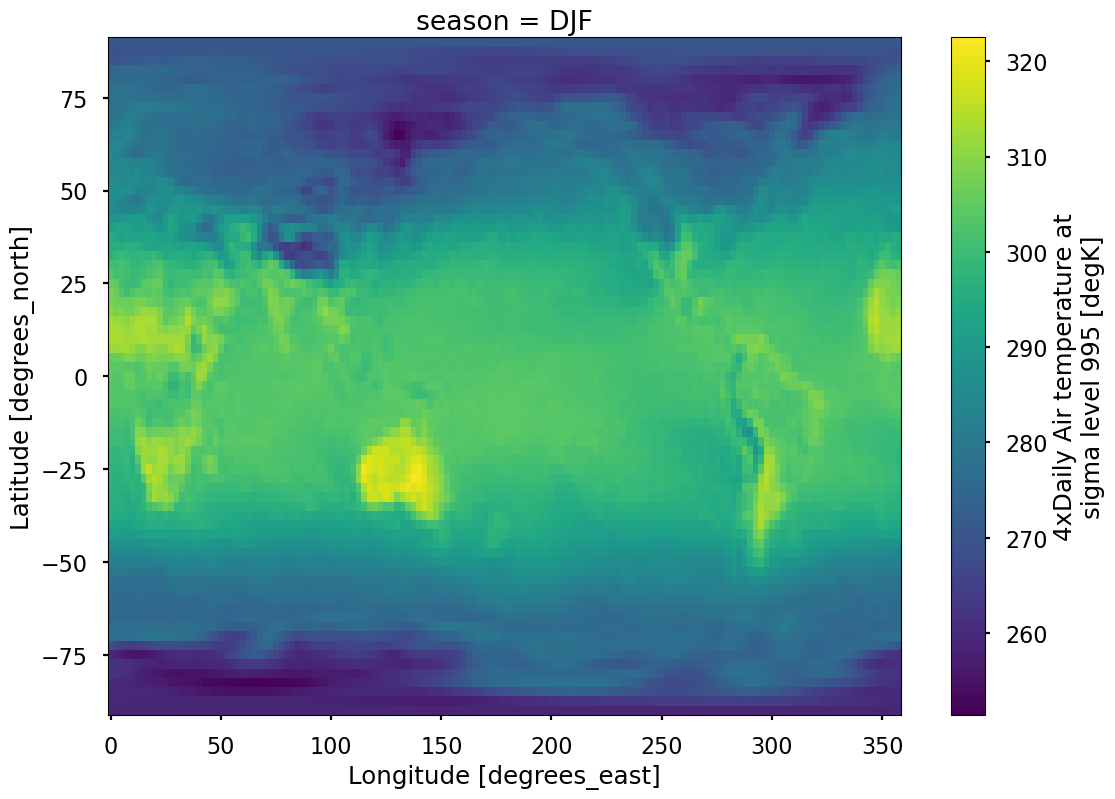

In [38]:
""" Calculate the hottest temperature recorded in each season. """
# use xarray features to calculate seasonal max
temp_max_ds = temp_ds.groupby("time.season").max()
temp_max_ds.sel(season = "DJF").air.plot()

In [39]:
""" Pull out season, lat, and lon arrays for plotting. """

lat = temp_max_ds.lat
lon = temp_max_ds.lon
season = temp_max_ds.season
season


<xarray.DataArray 'season' (season: 4)> Size: 32B
array(['DJF', 'JJA', 'MAM', 'SON'], dtype=object)
Coordinates:
  * season   (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'

## Multipanel plotting

The simplest approach to making a multipanel plot with `matplotlib` is to use `plt.subplots()`

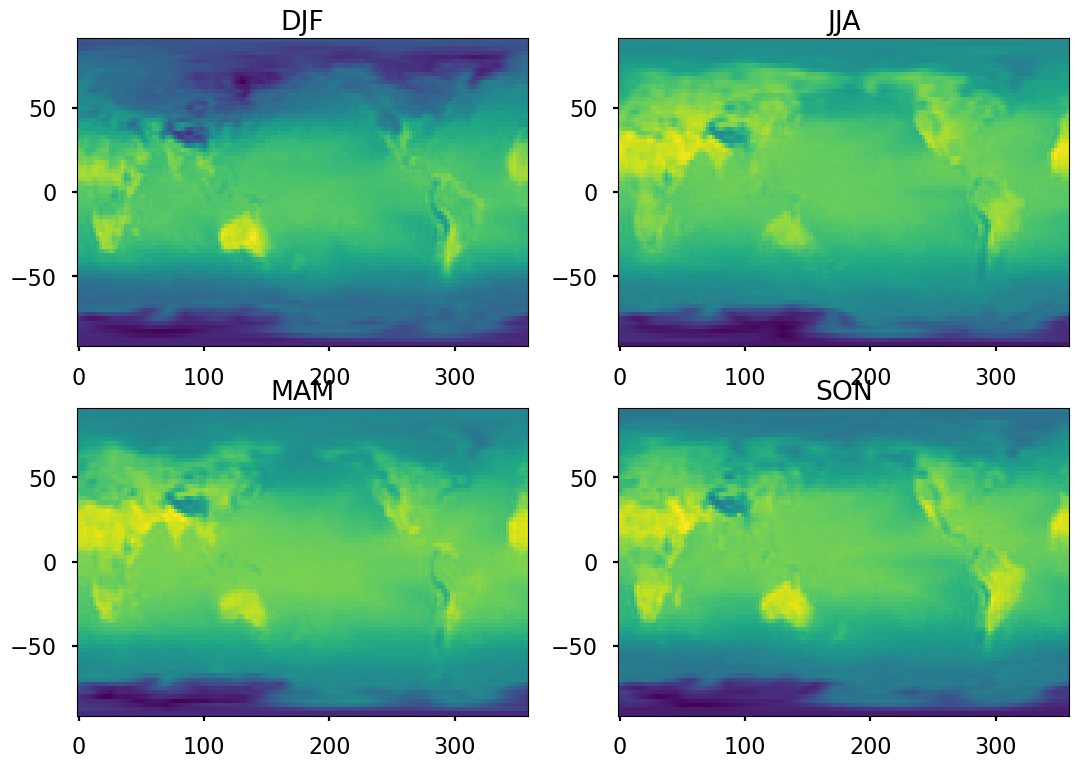

In [40]:
""" Generate a multipanel plot of seasonal max temperature, but only fill in the top left panel. """

fig, axs2d = plt.subplots(2,2)

# make the axis array one dimensional
axs = axs2d.ravel()

for ax, s in zip(axs, season):
    ax.pcolormesh(lon, lat, temp_max_ds.sel(season = s).air)
    ax.set_title(s.values)

plt.show()

### A sidenote about `zip`

If we want to loop over two things that have the same length, we can use the `zip()` function to loop over corresponding pairs of items in each list.

Say we have `list_1 = [0,1,2,3]` and `list_2 = ['i', 'j', 'k', 'l']`.  Then we can iterate over both using zip, e.g.,:

```
for x1, x2 in zip(list_1, list_2):
    print(x1,x2)
```

Try it below!

In [41]:
""" Test the `zip` function """
list_1 = [0,1,2,3]
list_2 = ['i','j','k','l']

for x1, x2 in zip(list_1, list_2):
    print(x1,x2)


0 i
1 j
2 k
3 l


We can use this to loop over the four seasons in `season` and the four plot panels in `axs`.

### Looping over panels

Use the code above and incorporate a for-loop with `zip` to plot all four seasons.

In [42]:
""" Plot data for each season using a for loop and zip"""


' Plot data for each season using a for loop and zip'

Great, now we have a four-panel plot.  But there are some things that I don't like about it:

1. It lacks a colorbar
2. There are no axis labels
3. I don't like the aspect ratio
4. The fonts look ugly to me
5. There's no need to repeat tick labels for each panel
6. There are no panel labels (e.g., panel '(a)')
7. This colormap is way over-used and probably isn't intuitive for temperature
8. It isn't obvious what season each panel corresponds to

We'll walk through these in action below.

In [46]:
""" Force dask to compute the max temperature for each season (saves time when repeating plots)"""

temp_max_ds.load


<bound method Dataset.load of <xarray.Dataset> Size: 169kB
Dimensions:  (season: 4, lat: 73, lon: 144)
Coordinates:
  * lat      (lat) float32 292B 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * season   (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
Data variables:
    air      (season, lat, lon) float32 168kB dask.array<chunksize=(1, 73, 144), meta=np.ndarray>
Attributes:
    Conventions:    COARDS
    title:          4x daily NMC reanalysis (2014)
    history:        created 2022/12 by Hoop (netCDF2.3)
    description:    Data is from NMC initialized reanalysis\n(4x/day).  These...
    platform:       Model
    dataset_title:  NCEP-NCAR Reanalysis 1
    References:     http://www.psl.noaa.gov/data/gridded/data.ncep.reanalysis...>

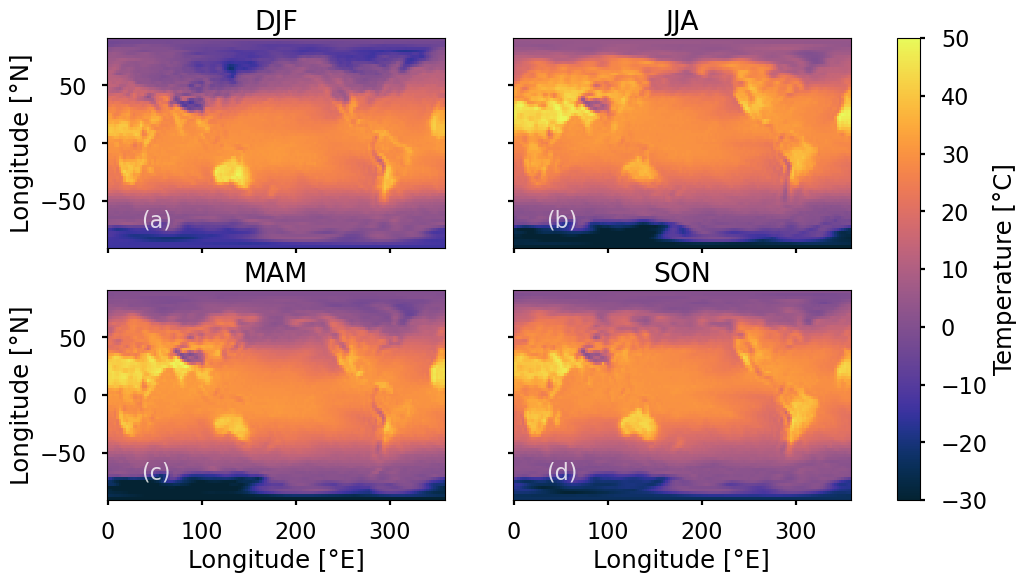

In [61]:
""" Make the plot look nice. """
fig, axs2d = plt.subplots(2,2, figsize=(12,6), sharex = True, sharey = True)

# make the axis array one dimensional
axs = axs2d.ravel()

labels = ["(a)","(b)","(c)","(d)"]

colormap = cmocean.cm.thermal

for ax, s, l in zip(axs, season, labels):
    cplot = ax.pcolormesh(lon, lat, temp_max_ds.sel(season = s).air - 273.15,
                          vmin = -30,
                          vmax = 50,
                          cmap = colormap,
                          )
    ax.set_title(s.values)
    ax.text(.1,.1,l,
            transform = ax.transAxes,
            color = "white",
            fontsize = 16,
            alpha = 0.8)

#add shared colorbar
plt.colorbar(cplot, ax=axs2d, label = "Temperature [°C]")

#add axis labels for the bottom row
for ax in axs2d[1,:]:
    ax.set_xlabel("Longitude [°E]")

for ax in axs2d[:,0]:
    ax.set_ylabel("Longitude [°N]")

plt.show()


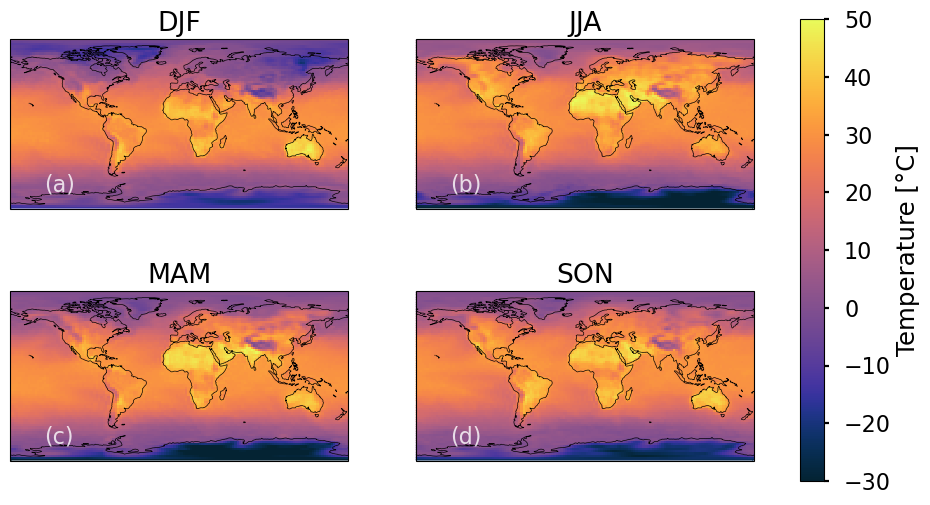

In [66]:
'''with cartopy'''

fig, axs2d = plt.subplots(2,2, figsize=(12,6), 
                          sharex = True, sharey = True,
                          subplot_kw = dict(projection = cartopy.crs.PlateCarree()))

# make the axis array one dimensional
axs = axs2d.ravel()

labels = ["(a)","(b)","(c)","(d)"]

colormap = cmocean.cm.thermal

for ax, s, l in zip(axs, season, labels):
    cplot = ax.pcolormesh(lon, lat, temp_max_ds.sel(season = s).air - 273.15,
                          vmin = -30,
                          vmax = 50,
                          cmap = colormap,
                          transform = cartopy.crs.PlateCarree()
                          )
    ax.set_title(s.values)
    ax.text(.1,.1,l,
            transform = ax.transAxes,
            color = "white",
            fontsize = 16,
            alpha = 0.8)
    ax.coastlines()

#add shared colorbar
plt.colorbar(cplot, ax=axs2d, label = "Temperature [°C]")

#add axis labels for the bottom row
for ax in axs2d[1,:]:
    ax.set_xlabel("Longitude [°E]")

for ax in axs2d[:,0]:
    ax.set_ylabel("Longitude [°N]")

#save fig
plt.savefig("fig_max_temp_season.png", dpi = 300, bbox_inches = "tight")

plt.show()

*Add a caption here*